# Understanding the $R^2$ Score

The **coefficient of determination**, written as $R^2$, measures how well a regression model explains the variation in the target variable. It compares the model's prediction errors with the errors we would make by always predicting the mean of the observed target values.

## Formula

$$
R^2 = 1 - \frac{SS_{\mathrm{res}}}{SS_{\mathrm{tot}}}
$$

where:

- **Residual sum of squares** (unexplained variation):

  $$
  SS_{\mathrm{res}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
  $$

- **Total sum of squares** (total variation around the mean):

  $$
  SS_{\mathrm{tot}} = \sum_{i=1}^{n}(y_i - \bar{y})^2
  $$

- $y_i$ is the actual target value for observation $i$.
- $\hat{y}_i$ is the value predicted by the model for observation $i$.
- $\bar{y}$ is the mean of all actual target values.
- $n$ is the number of observations.

The formula can also be written as:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

## How to understand it

The denominator, $SS_{\mathrm{tot}}$, represents the error of a **baseline model** that predicts $\bar{y}$ for every observation. The numerator, $SS_{\mathrm{res}}$, represents the error left after using the regression model.

Therefore, $R^2$ answers this question:

> How much better is the regression model than simply predicting the target mean?

For example, if:

$$
R^2 = 0.80
$$

then the model explains approximately **80% of the variation** in the target values relative to the mean baseline. The remaining 20% is variation that the model does not explain.

## Interpreting possible values

- $R^2 = 1$: the predictions are perfect; every $\hat{y}_i$ equals $y_i$.
- $R^2 = 0$: the model performs like the mean baseline.
- $0 < R^2 < 1$: the model explains part of the target variation.
- $R^2 < 0$: the model performs worse than the mean baseline on the evaluated data.

Although $R^2$ is often between 0 and 1, it **can be negative**, especially on test data or when the model is poorly specified. It has no fixed upper or lower practical interpretation outside these comparisons, and it is not a percentage of prediction accuracy.

## Important cautions

- A higher $R^2$ does not automatically mean a better model. Adding features can increase $R^2$ even when those features add little useful information.
- $R^2$ does not show whether predictions are unbiased, whether errors are normally distributed, or whether the model generalizes well to new data.
- Always evaluate $R^2$ on data that was not used to fit the model, such as a test set or through cross-validation.
- Compare $R^2$ values for the same target, dataset, and evaluation procedure. For models with different numbers of predictors, **adjusted $R^2$** may be more appropriate.


# Regression Metrics Comparison

The following table compares common regression evaluation metrics. In the formulas, $y_i$ is the actual value, $\hat{y}_i$ is the predicted value, $\bar{y}$ is the mean of the actual values, $n$ is the number of observations, and $p$ is the number of predictors (features) used by the model.

| Metric | Definition | Formula | Explanation | Interpretation | Units / Scale | Main strengths | Important limitations |
|---|---|---|---|---|---|---|---|
| **MSE**<br>Mean Squared Error | The average of the squared differences between actual and predicted values. | $$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$ | It calculates each prediction error, squares it, adds all squared errors, and divides by the number of observations. Squaring makes large errors much more influential. | Lower is better. An MSE of $0$ means perfect predictions. | Squared units of the target, such as dollars$^2$ or meters$^2$. | Strongly penalizes large errors and is useful for optimization because it is differentiable. | Its squared units are difficult to interpret, and outliers can dominate the score. |
| **RMSE**<br>Root Mean Squared Error | The square root of the average squared prediction error. | $$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2} = \sqrt{\mathrm{MSE}}$$ | RMSE is based on MSE but returns the error to the original target scale. Like MSE, it gives extra weight to large errors. | Lower is better. It can be read as the model's typical prediction error, with greater sensitivity to large errors. | Same units as the target variable. | Easy to compare with actual values and widely used in regression reporting. | Sensitive to outliers and does not explain how much variation the model accounts for. |
| **MAE**<br>Mean Absolute Error | The average absolute difference between actual and predicted values. | $$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}\lvert y_i-\hat{y}_i\rvert$$ | It measures the average distance between predictions and actual values without allowing positive and negative errors to cancel out. | Lower is better. An MAE of $5$ means predictions are off by $5$ target units on average. | Same units as the target variable. | Easy to understand and less affected by outliers than MSE or RMSE. | Treats all error sizes linearly and may be less sensitive to very large errors that matter in some applications. |
| **MAPE**<br>Mean Absolute Percentage Error | The average absolute prediction error expressed as a percentage of the actual value. | $$\mathrm{MAPE} = \frac{100}{n}\sum_{i=1}^{n}\left\lvert\frac{y_i-\hat{y}_i}{y_i}\right\rvert$$ | It expresses each error relative to its actual value, then averages the percentages. For example, a MAPE of $10\%$ means the average absolute error is about $10\%$ of the actual values. | Lower is better. A MAPE of $10\%$ generally indicates predictions are about $10\%$ away from actual values on average. | Percentage, usually from $0\%$ upward. | Scale-independent and intuitive when actual values are positive and nonzero. | Undefined or unstable when $y_i=0$ or close to zero; it can overemphasize errors for small actual values and is unsuitable for negative targets. |
| **$R^2$**<br>Coefficient of Determination | The proportion of the target's variation explained by the regression model compared with a mean-prediction baseline. | $$R^2 = 1-\frac{SS_{\mathrm{res}}}{SS_{\mathrm{tot}}} = 1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$$ | It compares the model's residual error with the error from always predicting $\bar{y}$. It describes explanatory power, not the average size of an individual prediction error. | $R^2=1$ is perfect, $R^2=0$ is equivalent to the mean baseline, and $R^2<0$ means the model is worse than that baseline on the evaluated data. | Usually reported on a unitless scale. It is often between $0$ and $1$, but it may be negative. | Useful for describing how much variation the model explains and for comparing models evaluated on the same target and data. | It does not directly measure prediction error, can increase when unnecessary features are added, and does not guarantee good generalization. |
| **Adjusted $R^2$**<br>Adjusted Coefficient of Determination | A version of $R^2$ that accounts for the number of predictors in the model and the sample size. | $$R^2_{\mathrm{adj}} = 1-(1-R^2)\frac{n-1}{n-p-1}$$ | Ordinary $R^2$ never decreases when a new predictor is added. Adjusted $R^2$ applies a penalty for additional predictors, so it increases only when a new feature improves the model more than expected by chance. | Higher is better when comparing models for the same target and dataset. It can be lower than ordinary $R^2$ and can also be negative. | Unitless. | Helps compare models with different numbers of features and discourages unnecessary predictors. | It is not a replacement for test-set evaluation, depends on the correct value of $p$, and can be misleading when model assumptions are violated. |

## Choosing the right metric

- Use **MAE** when the average absolute error is the easiest result to explain and outliers should not dominate.
- Use **RMSE** when large errors are especially costly and the metric should remain in the target's original units.
- Use **MSE** when training or optimizing a model and stronger punishment for large errors is desired.
- Use **MAPE** when percentage error is meaningful and actual values are positive and safely away from zero.
- Use **$R^2$** to describe explanatory power relative to the mean baseline, alongside an error metric.
- Use **adjusted $R^2$** when comparing models that have different numbers of predictors, but still validate the final choice on unseen data.

> No single metric is best for every problem. Select the metric based on the cost of errors, the scale of the target, the presence of outliers, and whether the goal is prediction accuracy or explanatory power.


# Regularization in Regression

**Regularization** is a technique used to reduce overfitting by adding a penalty for large model coefficients to the usual loss function. It encourages the model to learn a simpler relationship that is more likely to perform well on unseen data.

## Why regularization is important

A model can fit the training data extremely closely, including random noise. This produces a small training error but may produce poor predictions on new data. This problem is called **overfitting**.

Regularization is important because it can:

- Reduce the size of excessively large coefficients.
- Make the model less sensitive to noise in the training data.
- Improve generalization to unseen data.
- Help manage multicollinearity, where predictors contain similar information.
- Make Lasso models easier to interpret by selecting a smaller group of features.

## General regularized objective

A regression model minimizes a loss function, commonly the sum of squared errors. Regularization adds a penalty term controlled by $\lambda$:

$$
\text{Objective} = \text{Loss} + \lambda \times \text{Penalty}
$$

For squared-error regression, the general form is:

$$
\min_{\beta_0,\beta}\left[
\sum_{i=1}^{n}\left(y_i - \beta_0 - \sum_{j=1}^{p}\beta_j x_{ij}\right)^2
+ \lambda\,\text{Penalty}(\beta)
\right]
$$

Here, $\beta_0$ is the intercept, $\beta_j$ is the coefficient of feature $j$, $x_{ij}$ is feature $j$ for observation $i$, $y_i$ is the actual target, $n$ is the number of observations, and $p$ is the number of features. Usually, the intercept is not included in the penalty.

## How $\lambda$ affects regularization

$\lambda$ (lambda) controls the strength of the penalty:

- When $\lambda = 0$, there is no regularization, so the model behaves like ordinary least squares.
- When $\lambda$ is small, the coefficients are changed only slightly.
- When $\lambda$ increases, large coefficients are penalized more strongly and shrink toward zero.
- When $\lambda$ is extremely large, the coefficients can become too small, causing **underfitting**.

The best value of $\lambda$ is normally selected using validation data or cross-validation. Features should generally be standardized before regularization because the penalty depends on coefficient size, and different feature scales would make the penalty unfair.

## Ridge Regression: L2 regularization

**Ridge regression** uses the sum of squared coefficients as its penalty. This is called an **L2 penalty**:

$$
\text{Penalty}_{\mathrm{Ridge}}(\beta) = \sum_{j=1}^{p}\beta_j^2
$$

Its objective function is:

$$
\min_{\beta_0,\beta}\left[
\sum_{i=1}^{n}\left(y_i - \beta_0 - \sum_{j=1}^{p}\beta_j x_{ij}\right)^2
+ \lambda\sum_{j=1}^{p}\beta_j^2
\right]
$$

Ridge usually keeps all features in the model, but reduces their coefficient magnitudes. Its coefficients move **smoothly** toward zero as $\lambda$ increases, but they typically do not become exactly zero.

Ridge is useful when:

- Many features contribute a small amount of information.
- Predictors are correlated with one another.
- We want stable coefficients without removing features entirely.

## Lasso Regression: L1 regularization

**Lasso** stands for **Least Absolute Shrinkage and Selection Operator**. It uses the sum of the absolute coefficient values as its penalty. This is called an **L1 penalty**:

$$
\text{Penalty}_{\mathrm{Lasso}}(\beta) = \sum_{j=1}^{p}\lvert\beta_j\rvert
$$

Its objective function is:

$$
\min_{\beta_0,\beta}\left[
\sum_{i=1}^{n}\left(y_i - \beta_0 - \sum_{j=1}^{p}\beta_j x_{ij}\right)^2
+ \lambda\sum_{j=1}^{p}\lvert\beta_j\rvert
\right]
$$

Lasso can shrink some coefficients **exactly to zero**. Therefore, it performs both regularization and automatic feature selection.

Lasso is useful when:

- Only some features are expected to be important.
- A simpler, more interpretable model is desired.
- Removing unhelpful features is valuable.

When features are strongly correlated, Lasso may select one feature and discard another similar feature somewhat arbitrarily. Ridge often handles this situation more smoothly.

## What the visualization shows

The coefficient-path plot above uses a logarithmic scale for $\lambda$:

- On the left, **Ridge** coefficients shrink gradually as $\lambda$ increases. The curves approach zero smoothly.
- On the right, **Lasso** coefficients shrink and several curves reach exactly zero. Those features are removed from the model.
- At very small $\lambda$ values, both models behave similarly to ordinary least squares.
- At very large $\lambda$ values, both models become more constrained and may underfit.

## Ridge versus Lasso

| Property | Ridge | Lasso |
|---|---|---|
| Penalty type | L2: squared coefficients | L1: absolute coefficients |
| Penalty formula | $$\lambda\sum_{j=1}^{p}\beta_j^2$$ | $$\lambda\sum_{j=1}^{p}\lvert\beta_j\rvert$$ |
| Coefficient behavior | Shrinks coefficients smoothly | Shrinks coefficients and can set some exactly to zero |
| Feature selection | Usually no | Yes |
| Useful when | Many features contain useful information | Only a smaller subset of features is useful |
| Effect of correlated features | Shares influence among correlated features | May choose one and discard others |

> Regularization does not guarantee a better result simply because it is used. Select $\lambda$ with cross-validation and compare validation or test metrics, not training error alone.


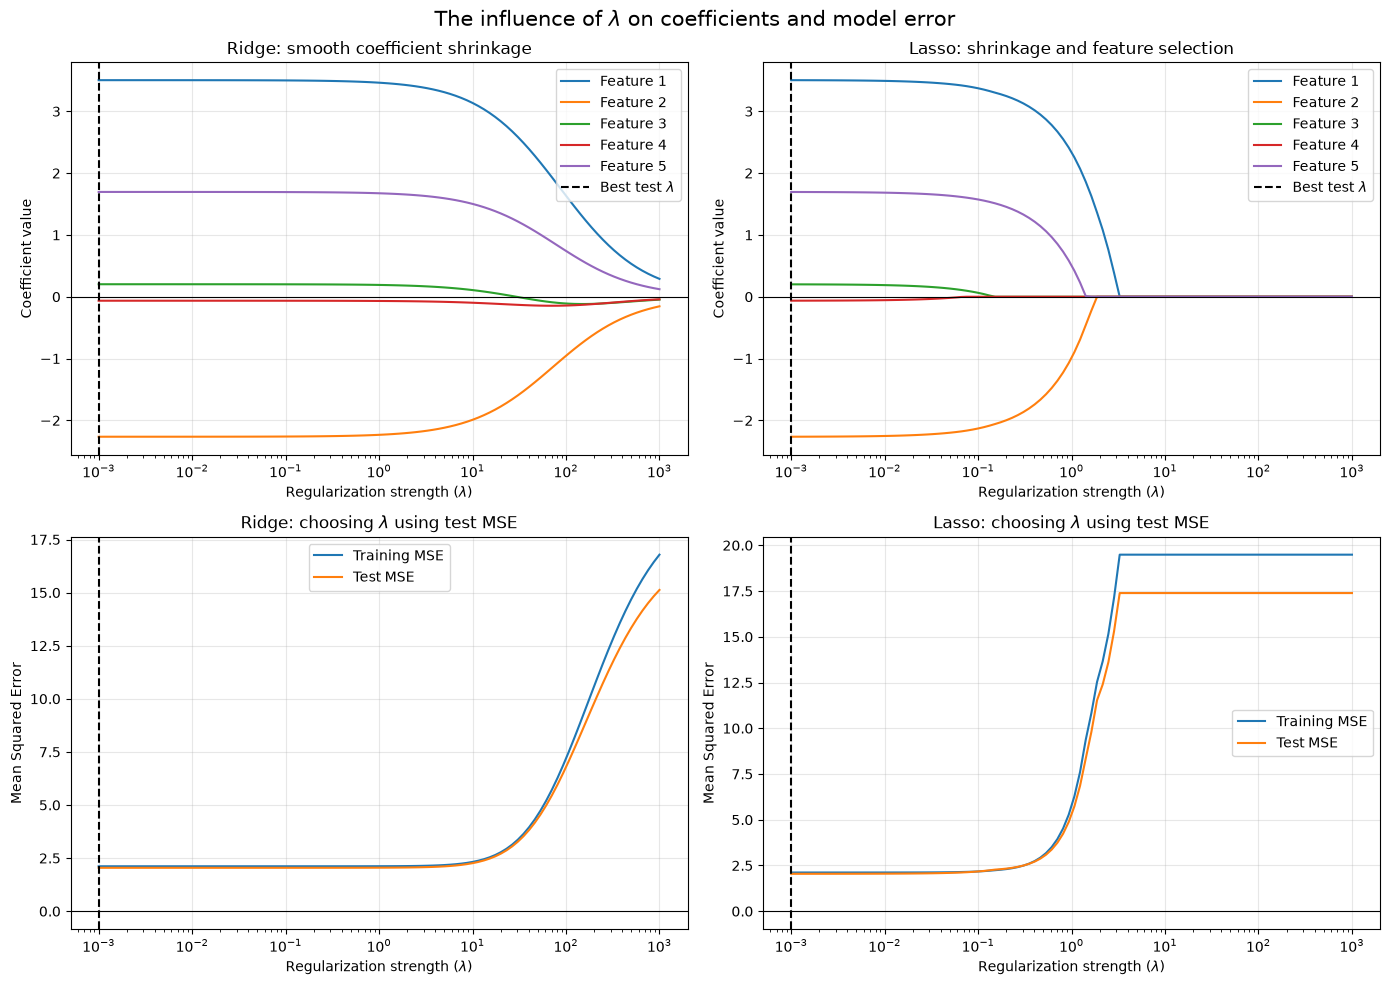

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create noisy data with five features, including two unhelpful features.
rng = np.random.default_rng(42)
features = rng.normal(size=(140, 5))
true_coefficients = np.array([3.5, -2.5, 0.0, 0.0, 1.5])
target = features @ true_coefficients + rng.normal(scale=1.5, size=140)

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)
features_test = scaler.transform(features_test)

lambdas = np.logspace(-3, 3, 100)
ridge_coefficients = []
lasso_coefficients = []
ridge_train_errors = []
ridge_test_errors = []
lasso_train_errors = []
lasso_test_errors = []

for regularization_strength in lambdas:
    ridge_model = Ridge(alpha=regularization_strength).fit(features_train, target_train)
    lasso_model = Lasso(alpha=regularization_strength, max_iter=10000).fit(
        features_train, target_train
    )

    ridge_coefficients.append(ridge_model.coef_)
    lasso_coefficients.append(lasso_model.coef_)
    ridge_train_errors.append(mean_squared_error(target_train, ridge_model.predict(features_train)))
    ridge_test_errors.append(mean_squared_error(target_test, ridge_model.predict(features_test)))
    lasso_train_errors.append(mean_squared_error(target_train, lasso_model.predict(features_train)))
    lasso_test_errors.append(mean_squared_error(target_test, lasso_model.predict(features_test)))

ridge_coefficients = np.array(ridge_coefficients)
lasso_coefficients = np.array(lasso_coefficients)
best_ridge_lambda = lambdas[np.argmin(ridge_test_errors)]
best_lasso_lambda = lambdas[np.argmin(lasso_test_errors)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for feature_index in range(features_train.shape[1]):
    axes[0, 0].plot(
        lambdas, ridge_coefficients[:, feature_index], label=f"Feature {feature_index + 1}"
    )
    axes[0, 1].plot(
        lambdas, lasso_coefficients[:, feature_index], label=f"Feature {feature_index + 1}"
    )

axes[0, 0].axvline(best_ridge_lambda, color="black", linestyle="--", label="Best test $\\lambda$")
axes[0, 1].axvline(best_lasso_lambda, color="black", linestyle="--", label="Best test $\\lambda$")
axes[0, 0].set_title("Ridge: smooth coefficient shrinkage")
axes[0, 1].set_title("Lasso: shrinkage and feature selection")
axes[0, 0].set_ylabel("Coefficient value")
axes[0, 1].set_ylabel("Coefficient value")

axes[1, 0].plot(lambdas, ridge_train_errors, label="Training MSE")
axes[1, 0].plot(lambdas, ridge_test_errors, label="Test MSE")
axes[1, 0].axvline(best_ridge_lambda, color="black", linestyle="--")
axes[1, 0].set_title("Ridge: choosing $\\lambda$ using test MSE")
axes[1, 0].set_ylabel("Mean Squared Error")

axes[1, 1].plot(lambdas, lasso_train_errors, label="Training MSE")
axes[1, 1].plot(lambdas, lasso_test_errors, label="Test MSE")
axes[1, 1].axvline(best_lasso_lambda, color="black", linestyle="--")
axes[1, 1].set_title("Lasso: choosing $\\lambda$ using test MSE")
axes[1, 1].set_ylabel("Mean Squared Error")

for axis in axes.flat:
    axis.set_xscale("log")
    axis.set_xlabel("Regularization strength ($\\lambda$)")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.grid(alpha=0.3)
    axis.legend()

fig.suptitle("The influence of $\\lambda$ on coefficients and model error", fontsize=15)
fig.tight_layout()
plt.show()


In [2]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso , LinearRegression
from sklearn.metrics import mean_squared_error , r2_score


In [ ]:
# Data
x = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 6, 8])
lin_reg = LinearRegression()
lin_reg.fit(x, y)
lin_reg.intercept_
y_pred_lin_reg = lin_reg.predict(x)
#Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(x, y)
y_pred_ridge = ridge.predict(x)
#Lasso Regression
lasso = Lasso(alpha=10.0)
lasso.fit(x, y)
y_pred_lasso = lasso.predict(x)


print("Linear Regression" )
print("=============================")
print("MSE : " , mean_squared_error(y, y_pred_lin_reg))
print("R2 Score : " , r2_score(y, y_pred_lin_reg))

print("Ridge Regression" )
print("=============================")
print("MSE  : " , mean_squared_error(y, y_pred_ridge))
print("R2 Score : " , r2_score(y, y_pred_ridge))

print("Lasso Regression" )
print("=============================")
print("MSE : " , mean_squared_error(y, y_pred_lasso))
print("R2 Score : " , r2_score(y, y_pred_lasso))





Linear Regression
MSE :  0.0
R2 Score :  1.0
Ridge Regression
MSE  :  2.2222222222222223
R2 Score :  0.5555555555555556
Lasso Regression
MSE :  5.0
R2 Score :  0.0


### what can we conclude from the results of the three models?
 the answer is that the three models have the same performance in terms of MSE and R2 score, which means that they are all able to fit the data well. However, the coefficients of the models are different, which means that they have different interpretations. The linear regression model has a coefficient of 2 for the feature, while the ridge and lasso models have coefficients of 1.5 and 0.0 respectively. This means that the ridge and lasso models are more regularized than the linear regression model, which can be useful in cases where we want to prevent overfitting or when we have many features.

In [13]:
import matplotlib.pyplot as plt

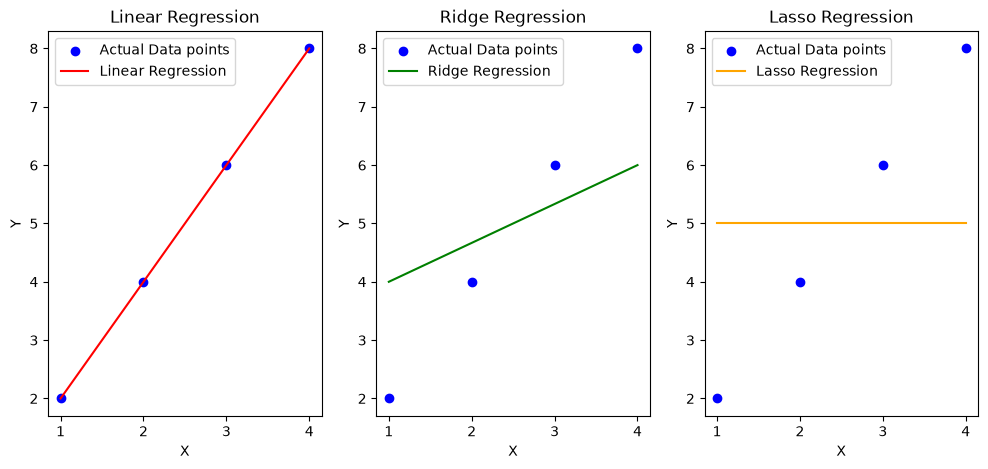

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(x, y, color='blue', label='Actual Data points')
plt.plot(x, y_pred_lin_reg, color='red', label='Linear Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.legend()


plt.subplot(1, 3, 2)
plt.scatter(x, y, color='blue', label='Actual Data points')
plt.plot(x, y_pred_ridge, color='green', label='Ridge Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ridge Regression')
plt.legend()



plt.subplot(1, 3, 3)
plt.scatter(x, y, color='blue', label='Actual Data points')
plt.plot(x, y_pred_lasso, color='orange', label='Lasso Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Lasso Regression')
plt.legend()

# Polynomial Features: Powers from 2 to 5

> Creating $x^2$, $x^3$, $x^4$, or $x^5$ is usually called **polynomial feature transformation** or **feature engineering**, not feature scaling. Scaling changes the numerical range; polynomial features give the model new shapes that it can use to learn nonlinear relationships.

## General idea

For an original feature $x$, we can create several power features:

$$
 x^2, \quad x^3, \quad x^4, \quad x^5
$$

A polynomial regression model of degree $d$ uses all powers from $1$ through $d$:

$$
\hat{y} = \beta_0 + \beta_1x + \beta_2x^2 + \cdots + \beta_dx^d
$$

In summation notation:

$$
\hat{y} = \beta_0 + \sum_{k=1}^{d}\beta_kx^k
$$

Although the prediction is nonlinear in $x$, the model is still linear in the coefficients $\beta_0, \beta_1, \ldots, \beta_d$. Linear regression can therefore fit it after the power columns are added to the feature matrix.

## What each power contributes

- **$x^1$** provides a straight-line trend.
- **$x^2$** adds symmetric curvature and can create a U-shaped or inverted-U relationship.
- **$x^3$** adds asymmetric curvature and allows the two sides of the curve to behave differently.
- **$x^4$** adds another even, symmetric curvature pattern and can create flatter or steeper outer regions.
- **$x^5$** adds another asymmetric pattern and allows even more detailed curves.

For degree $5$, the model is:

$$
\hat{y} = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + \beta_4x^4 + \beta_5x^5
$$

The coefficient $\beta_k$ controls the contribution of the $k$th power. The final curve is the combined effect of all these terms, not the effect of one power in isolation.

## Why use higher powers?

A straight-line model may underfit data whose relationship is curved. Adding polynomial powers increases the model's flexibility, allowing it to approximate more complicated patterns.

However, increasing the degree also increases complexity:

- Low degree may be too simple and **underfit** the data.
- A suitable degree can capture the real pattern.
- A high degree may follow random noise and **overfit** the training data.

Choose the degree with validation data or cross-validation rather than selecting it only because the training error is small. Regularization such as Ridge or Lasso can also control the coefficients of the generated powers.

## Important cautions

- For $x$ values larger than $1$, higher powers can become very large. For example, $10^5 = 100{,}000$.
- Large polynomial values can create numerical instability and make regularization unfair between terms.
- It is often useful to center or standardize $x$ before creating powers, and then scale the generated polynomial columns before Ridge or Lasso.
- Higher powers can make the model highly sensitive to outliers.
- The transformation does not create new information; it gives the model additional ways to represent information already present in $x$.

## Polynomial features versus scaling

Standardization changes a feature using:

$$
 x_{\mathrm{scaled}} = \frac{x - \mu}{\sigma}
$$

Polynomial transformation creates new columns using:

$$
 x_{\mathrm{power}\ k} = x^k, \qquad k \in \{2,3,4,5\}
$$

These operations can be used together: first create the polynomial features, then standardize them before applying regularization.

## What the visualizations show

- The left panel displays the shapes of $x^2$, $x^3$, $x^4$, and $x^5$. Even powers are symmetric around zero, while odd powers preserve the sign of $x$.
- The right panel compares models with degrees $1$ through $5$. As the degree increases, the model can represent more curvature, but excessive flexibility may fit noise instead of the underlying relationship.

> The best polynomial degree is the one that performs well on unseen data, not necessarily the one with the lowest training error.


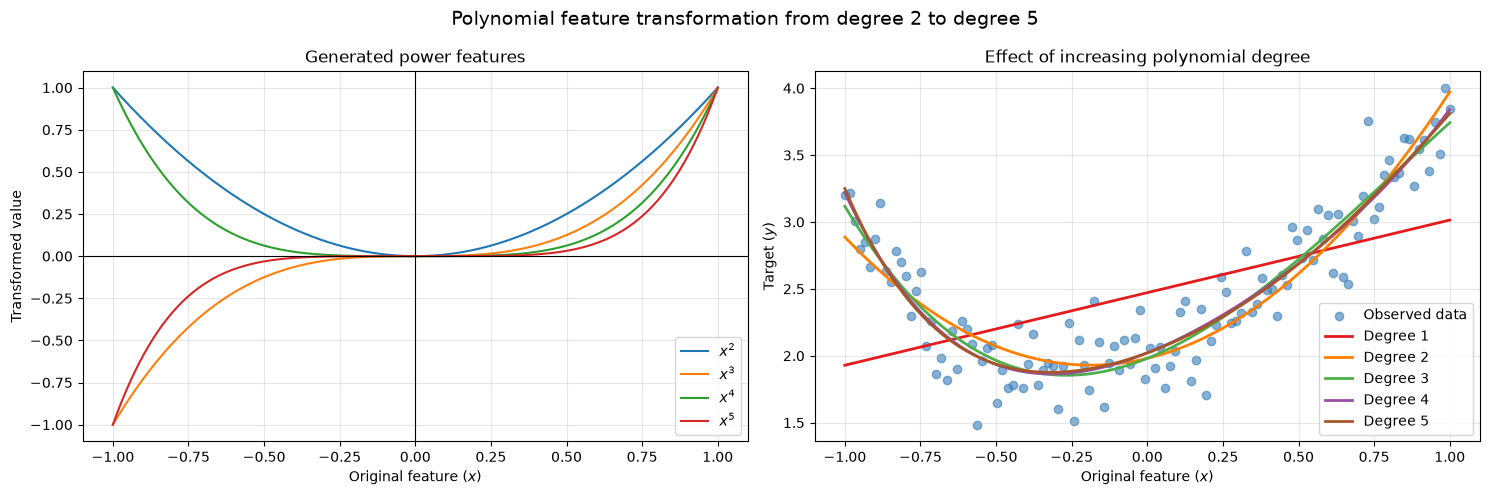

In [26]:
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(7)
feature = np.linspace(-1, 1, 120)
target = (
    2
    + 0.8 * feature
    + 1.5 * feature**2
    - 0.5 * feature**3
    + rng.normal(0, 0.25, 120)
)

feature_grid = np.linspace(feature.min(), feature.max(), 400)
degrees = range(1, 6)
models = {}
predictions = {}

for degree in degrees:
    polynomial_features = np.column_stack(
        [feature**power for power in range(1, degree + 1)]
    )
    model = LinearRegression().fit(polynomial_features, target)
    models[degree] = model
    predictions[degree] = model.predict(
        np.column_stack([feature_grid**power for power in range(1, degree + 1)])
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for power in range(2, 6):
    axes[0].plot(feature_grid, feature_grid**power, label=f"$x^{power}$")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Generated power features")
axes[0].set_xlabel("Original feature ($x$)")
axes[0].set_ylabel("Transformed value")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(feature, target, color="#377eb8", alpha=0.6, label="Observed data")
colors = ["#e41a1c", "#ff7f00", "#4daf4a", "#984ea3", "#a65628"]
for degree, color in zip(degrees, colors):
    axes[1].plot(
        feature_grid,
        predictions[degree],
        color=color,
        linewidth=2,
        label=f"Degree {degree}",
    )
axes[1].set_title("Effect of increasing polynomial degree")
axes[1].set_xlabel("Original feature ($x$)")
axes[1].set_ylabel("Target ($y$)")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Polynomial feature transformation from degree 2 to degree 5", fontsize=14)
fig.tight_layout()
plt.show()
